# Daftar Isi

- [Impor Pustaka](#scrollTo=kBfZS8wO0szK)
- [Unggah Dataset](#scrollTo=CmBuQOCu08bS)
- [Ekstrak Dataset](#scrollTo=QrujonWC2OFl)
- [Atur Jalur Dasar Dataset](#scrollTo=cpqDYvcx2SKq)
- [Daftar Isi Dataset](#scrollTo=hsBjBu9Y2UKi)
- [Hitung Data per Kelas](#scrollTo=qe0OvLke2XcP)
- [Visualisasi Distribusi Dataset](#scrollTo=Y5K6pY4X2e2j)
- [Bersihkan Dataset (Hapus File Rusak)](#scrollTo=TNQm9_LC27Qw)
- [Ubah Ukuran dan Konversi Gambar](#scrollTo=-NPBzayu2_XJ)
- [Tampilkan Contoh Gambar](#scrollTo=XfIaFHyj3JJm)
- [Simpan Dataset yang Sudah Diproses](#scrollTo=jeZIDzZX6EjO)
- [Verifikasi Dataset yang Sudah Diproses](#scrollTo=_dsEpo_b6LPH)
- [Siapkan Generator Data](#scrollTo=JA-KaCsc6Olj)
- [Tampilkan Label Kelas](#scrollTo=pnoebT7y6TnP)
- [Arsipkan Dataset yang Sudah Diproses](#scrollTo=fSDBkr_X6Yww)
- [Unduh Dataset yang Sudah Diarsipkan](#scrollTo=__pYnfr96cNp)
- [Tampilkan Contoh Gambar dari Data Pelatihan](#scrollTo=I_cJFT5_6n6G)

## Impor Pustaka
Sel ini mengimpor semua pustaka Python yang diperlukan untuk operasi file, pemrosesan gambar, plotting, dan pembuatan data gambar TensorFlow.

In [ ]:
import os
import zipfile
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Unggah Dataset
Sel ini menggunakan `google.colab.files` untuk memungkinkan pengguna mengunggah file zip yang berisi dataset dari mesin lokal mereka ke lingkungan Colab.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ss chat.zip to ss chat.zip


## Ekstrak Dataset
Sel ini mengekstrak isi file zip yang diunggah ke direktori yang ditentukan `/content/dataset`.

In [ ]:
zip_path = "ss chat.zip"  # ganti sesuai nama file
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak!")

Dataset berhasil diekstrak!


## Atur Jalur Dasar Dataset
Sel ini mendefinisikan direktori dasar tempat dataset yang diekstrak berada untuk pemrosesan lebih lanjut.

In [ ]:
base_path = "/content/dataset"

## Daftar Isi Dataset
Sel ini mencetak isi (folder/subdirektori) di dalam `base_path` untuk memverifikasi struktur dataset yang diekstrak.

In [ ]:
print("Isi folder dataset:")
print(os.listdir(base_path))

Isi folder dataset:
['ss chat', 'organ']


## Hitung Data per Kelas
Sel ini mengiterasi melalui subdirektori di `base_path` untuk menghitung jumlah file gambar di setiap kelas (folder) dan menyimpannya dalam daftar `labels` dan `counts`.

In [ ]:
labels = []
counts = []

print("\nJumlah data per kelas:")

for folder in os.listdir(base_path):
    path = os.path.join(base_path, folder)
    if os.path.isdir(path):
        jumlah = len(os.listdir(path))
        print(folder, ":", jumlah)
        labels.append(folder)
        counts.append(jumlah)


Jumlah data per kelas:
ss chat : 200
organ : 1364


## Visualisasi Distribusi Dataset
Sel ini membuat plot batang untuk memvisualisasikan distribusi gambar di berbagai kelas, menunjukkan jumlah gambar per kategori.

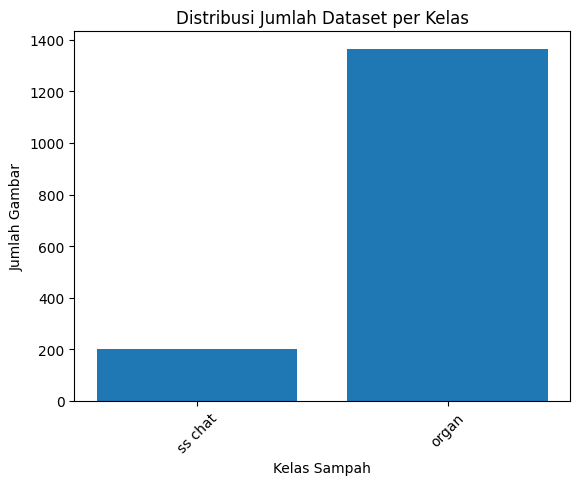

In [ ]:
plt.figure()
plt.bar(labels, counts)
plt.xticks(rotation=45)
plt.title("Distribusi Jumlah Dataset per Kelas")
plt.xlabel("Kelas Sampah")
plt.ylabel("Jumlah Gambar")
plt.show()

## Bersihkan Dataset (Hapus File Rusak)
Sel ini mengiterasi melalui semua file gambar dalam dataset untuk mengidentifikasi dan menghapus file gambar yang rusak, kosong, atau tidak dapat dibaca. Ini menggunakan `Image.verify()` dari PIL untuk validasi.

In [ ]:
for folder in os.listdir(base_path):
    path = os.path.join(base_path, folder)

    if os.path.isdir(path):
        for file in os.listdir(path):
            file_path = os.path.join(path, file)

            try:
                if os.path.getsize(file_path) == 0:
                    os.remove(file_path)
                    continue

                img = Image.open(file_path)
                img.verify()

            except:
                print("Hapus:", file_path)
                os.remove(file_path)

## Ubah Ukuran dan Konversi Gambar
Sel ini mengiterasi melalui semua gambar dalam dataset, membukanya, mengubahnya ke format RGB, mengubah ukurannya menjadi 224x224 piksel, dan kemudian menyimpannya kembali ke lokasi aslinya. Ini menstandardisasi dimensi gambar dan saluran warna.

In [ ]:
size = (224, 224)

for folder in os.listdir(base_path):
    path = os.path.join(base_path, folder)

    if os.path.isdir(path):
        for file in os.listdir(path):
            file_path = os.path.join(path, file)

            try:
                img = Image.open(file_path).convert("RGB")
                img = img.resize(size)
                img.save(file_path)
            except:
                pass

print("Resize selesai!")

Resize selesai!


## Tampilkan Contoh Gambar
Sel ini menampilkan satu contoh gambar dari setiap kelas untuk memeriksa dataset secara visual setelah pengubahan ukuran dan pembersihan.

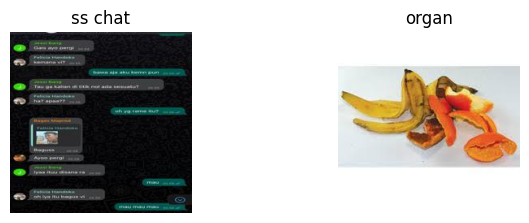

In [ ]:
plt.figure(figsize=(12,8))

i = 1
for folder in os.listdir(base_path):
    path = os.path.join(base_path, folder)
    if os.path.isdir(path):
        file = os.listdir(path)[0]
        img_path = os.path.join(path, file)

        img = Image.open(img_path)

        plt.subplot(3,3,i)
        plt.imshow(img)
        plt.title(folder)
        plt.axis('off')
        i += 1

plt.show()

## Simpan Dataset yang Sudah Diproses
Sel ini membuat direktori baru `/content/ss` dan menyalin semua gambar yang sudah diproses (diubah ukurannya menjadi 224x224, dikonversi ke RGB) ke dalamnya, memastikan bahwa hanya gambar yang valid yang ditransfer. Ini membuat dataset yang bersih dan seragam untuk pelatihan model.

In [ ]:
output_path = "/content/ss"
os.makedirs(output_path, exist_ok=True)

for folder in os.listdir(base_path):
    input_folder = os.path.join(base_path, folder)
    output_folder = os.path.join(output_path, folder)

    if os.path.isdir(input_folder):
        os.makedirs(output_folder, exist_ok=True)

        for file in os.listdir(input_folder):
            input_file = os.path.join(input_folder, file)
            output_file = os.path.join(output_folder, file)

            try:
                if os.path.getsize(input_file) == 0:
                    continue

                img = Image.open(input_file).convert("RGB")
                img = img.resize((224, 224))
                img.save(output_file)

            except:
                print("Skip:", input_file)

print("✅ Dataset preprocessing berhasil disimpan!")

✅ Dataset preprocessing berhasil disimpan!


## Verifikasi Dataset yang Sudah Diproses
Sel ini mencetak jumlah gambar di setiap kelas di dalam direktori dataset yang baru dibuat (`output_path`) untuk mengonfirmasi keberhasilan pemrosesan awal dan organisasi.

In [ ]:
print("\nCek dataset hasil preprocessing:")

for folder in os.listdir(output_path):
    path = os.path.join(output_path, folder)
    print(folder, ":", len(os.listdir(path)))


Cek dataset hasil preprocessing:
ss chat : 200
organ : 1364


## Siapkan Generator Data
Sel ini menginisialisasi `ImageDataGenerator` untuk augmentasi dan normalisasi data (menskalakan nilai piksel ke 0-1) dan kemudian membuat generator `train_data` dan `val_data` untuk pelatihan dan validasi, memisahkan dataset dan mengacaknya.

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    output_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    output_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

Found 1252 images belonging to 2 classes.
Found 312 images belonging to 2 classes.


## Tampilkan Label Kelas
Sel ini mencetak pemetaan nama kelas ke indeks numeriknya seperti yang ditentukan oleh `ImageDataGenerator`.

In [ ]:
print("\nLabel kelas:")
print(train_data.class_indices)


Label kelas:
{'organ': 0, 'ss chat': 1}


## Arsipkan Dataset yang Sudah Diproses
Sel ini membuat arsip zip bernama `ss.zip` dari direktori yang berisi gambar-gambar yang telah diproses (`output_path`).

In [ ]:
import shutil

shutil.make_archive("ss", 'zip', output_path)

'/content/ss.zip'

## Unduh Dataset yang Sudah Diarsipkan
Sel ini memfasilitasi pengunduhan file `ss.zip`, yang berisi dataset yang telah diproses, ke mesin lokal pengguna.

In [ ]:
from google.colab import files
files.download("ss.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Tampilkan Contoh Gambar dari Data Pelatihan
Sel ini mengambil batch gambar dan labelnya dari generator `train_data` dan menampilkan 6 gambar pertama dengan nama kelas yang sesuai, memverifikasi proses pemuatan dan pelabelan data.

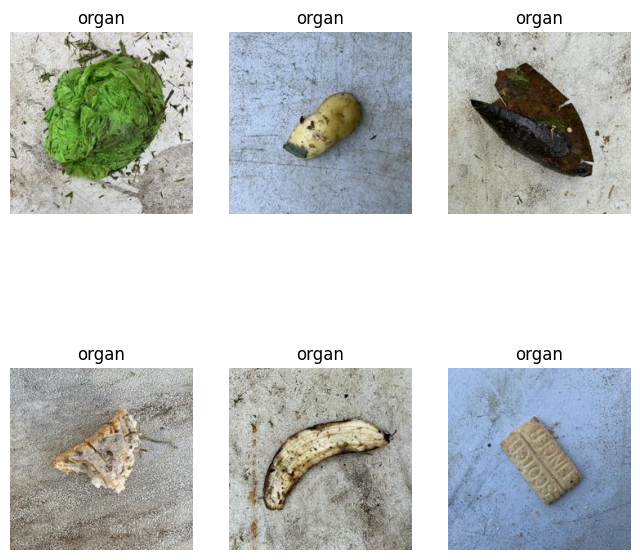

In [ ]:
class_names = list(train_data.class_indices.keys())

images, labels_batch = next(train_data)

plt.figure(figsize=(8,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    label_index = labels_batch[i].argmax()
    plt.title(class_names[label_index])
    plt.axis('off')

plt.show()